# Part 1 – Baseline Classifier

## 1. Import

In [1]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if DEVICE=="cuda" else "N/A"}')

Device: cuda
GPU: NVIDIA GeForce RTX 3060


## 2. Load data & create stratified subsets

In [ ]:
DATA_PATH = 'jigsaw-unintended-bias-train.csv'

COLS_NEEDED = ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish']
df_full = pd.read_csv(DATA_PATH, usecols=COLS_NEEDED)
print(f'Full dataset shape: {df_full.shape}')
df_full.head(3)

Full dataset shape: (1902194, 6)


,comment_text,toxic,black,jewish,muslim,white
0,"This is so cool. It's like, 'would you want yo...",0.0,NaN,NaN,NaN,NaN
1,Thank you!! This would make my life a lot less...,0.0,NaN,NaN,NaN,NaN
2,This is such an urgent design problem; kudos t...,0.0,NaN,NaN,NaN,NaN


In [4]:
# Binarize: toxic >= 0.5 -> 1, else 0
df_full['label'] = (df_full['toxic'] >= 0.5).astype(int)
print(f'Class distribution:\n{df_full["label"].value_counts()}')
print(f'Toxic rate: {df_full["label"].mean():.3f}')

Class distribution:
label
0    1750083
1     152111
Name: count, dtype: int64
Toxic rate: 0.080


In [5]:
# Stratified sample: 100k train + 20k eval
# Step 1: sample 120k from full dataset, stratified on label
df_sample, _ = train_test_split(
    df_full,
    train_size=120_000,
    stratify=df_full['label'],
    random_state=SEED,
)

# Check class distribution in sample before second split
print(f"Sample class distribution:\n{df_sample['label'].value_counts()}")

# Step 2: split 120k into 100k train / 20k eval
# Use shuffle split instead of stratified to avoid the "only 1 member" error
from sklearn.model_selection import ShuffleSplit
rs = ShuffleSplit(n_splits=1, test_size=20_000, random_state=SEED)
train_idx, eval_idx = next(rs.split(df_sample))
df_train = df_sample.iloc[train_idx].reset_index(drop=True)
df_eval  = df_sample.iloc[eval_idx].reset_index(drop=True)

print(f'Train shape : {df_train.shape} | toxic rate: {df_train["label"].mean():.3f}')
print(f'Eval  shape : {df_eval.shape}  | toxic rate: {df_eval["label"].mean():.3f}')

# Persist eval set for all downstream parts
df_eval.to_csv('eval_set.csv', index=False)
print('Saved eval_set.csv')

Sample class distribution:
label
0    110404
1      9596
Name: count, dtype: int64
Train shape : (100000, 7) | toxic rate: 0.080
Eval  shape : (20000, 7)  | toxic rate: 0.080
Saved eval_set.csv


## 3. Tokenization & Dataset class

In [6]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class JigsawDataset(Dataset):
    def __init__(self, texts, labels, tok, max_len=MAX_LEN):
        self.enc = tok(
            list(texts),
            padding='max_length',
            truncation=True,
            max_length=max_len,
            return_tensors='pt',
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.enc['input_ids'][idx],
            'attention_mask': self.enc['attention_mask'][idx],
            'labels':         self.labels[idx],
        }

print('Tokenizing training set')
train_dataset = JigsawDataset(df_train['comment_text'], df_train['label'], tokenizer)
print('Tokenizing evaluation set')
eval_dataset  = JigsawDataset(df_eval['comment_text'],  df_eval['label'],  tokenizer)
print('Done.')

Tokenizing training set
Tokenizing evaluation set …
Done.


## 4. Fine-tune DistilBERT (3 epochs)

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1':       f1_score(labels, preds, average='macro'),
        'auc':      roc_auc_score(labels, probs),
    }

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

training_args = TrainingArguments(
    output_dir            = './baseline_model',
    num_train_epochs      = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_ratio          = 0.1,
    weight_decay          = 0.01,
    learning_rate         = 2e-5,
    eval_strategy         = 'epoch',
    save_strategy         = 'epoch',
    load_best_model_at_end= True,
    metric_for_best_model = 'f1',
    fp16                  = (DEVICE == 'cuda'),
    logging_steps         = 200,
    report_to             = 'none',
    seed                  = SEED,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = eval_dataset,
    compute_metrics = compute_metrics,
)

print('Starting training …')
trainer.train()
print('Training complete.')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1203.98it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting training …


Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,0.136705,0.142226,0.950450,0.806971,0.943034
2,0.112841,0.150121,0.945500,0.814454,0.946057
3,0.079781,0.180703,0.947650,0.813124,0.941122


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.37it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training complete.


In [8]:
# Save the baseline checkpoint
trainer.save_model('./baseline_model')
tokenizer.save_pretrained('./baseline_model')
print('Baseline model saved to ./baseline_model')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.13it/s]


Baseline model saved to ./baseline_model


## 5. Evaluation at default threshold (0.5)

In [9]:
predictions = trainer.predict(eval_dataset)
logits      = predictions.predictions          # shape (N, 2)
true_labels = predictions.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
preds = (probs >= 0.5).astype(int)

acc  = accuracy_score(true_labels, preds)
f1   = f1_score(true_labels, preds, average='macro')
auc  = roc_auc_score(true_labels, probs)
cm   = confusion_matrix(true_labels, preds)

print('=== Evaluation @ threshold=0.5 ===')
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1 (macro): {f1:.4f}')
print(f'  AUC-ROC   : {auc:.4f}')
print(f'\nConfusion matrix:\n{cm}')

# Save probabilities for downstream use
np.save('eval_probs.npy', probs)
print('Saved eval_probs.npy')

=== Evaluation @ threshold=0.5 ===
  Accuracy  : 0.9456
  F1 (macro): 0.8146
  AUC-ROC   : 0.9461

Confusion matrix:
[[17860   539]
 [  550  1051]]
Saved eval_probs.npy


## 6. Threshold selection

In [10]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for t in thresholds:
    p = (probs >= t).astype(int)
    threshold_results.append({
        'threshold': t,
        'accuracy':  accuracy_score(true_labels, p),
        'f1_macro':  f1_score(true_labels, p, average='macro'),
        'f1_toxic':  f1_score(true_labels, p, pos_label=1),
        'precision': np.sum((p==1) & (true_labels==1)) / max(np.sum(p==1), 1),
        'recall':    np.sum((p==1) & (true_labels==1)) / max(np.sum(true_labels==1), 1),
    })

df_thresh = pd.DataFrame(threshold_results)
print(df_thresh.to_string(index=False))

 threshold  accuracy  f1_macro  f1_toxic  precision   recall
       0.3   0.93735  0.806481  0.647340   0.589139 0.718301
       0.4   0.94320  0.814849  0.660693   0.633085 0.690818
       0.5   0.94555  0.814571  0.658728   0.661006 0.656465
       0.6   0.94820  0.815590  0.659211   0.696317 0.625859
       0.7   0.95010  0.813532  0.653953   0.734996 0.589007


## 7. Plots

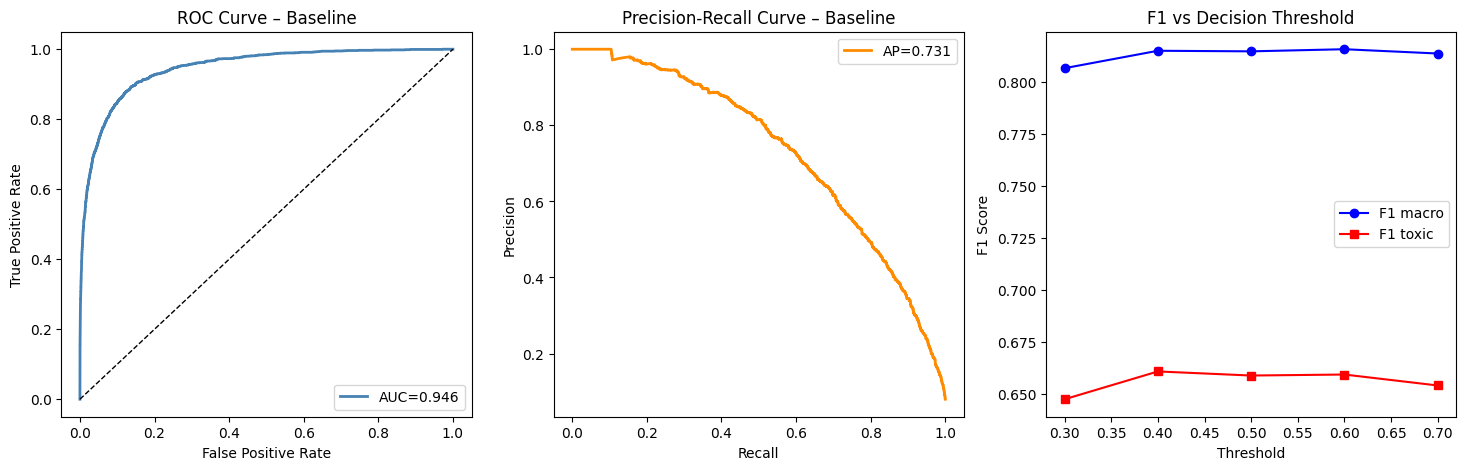

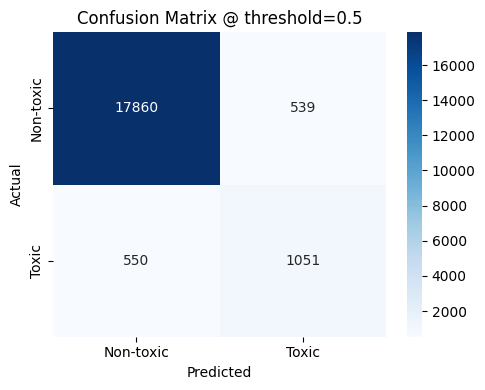

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve
fpr_vals, tpr_vals, _ = roc_curve(true_labels, probs)
axes[0].plot(fpr_vals, tpr_vals, color='steelblue', lw=2, label=f'AUC={auc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve – Baseline')
axes[0].legend()

# PR curve
prec_vals, rec_vals, _ = precision_recall_curve(true_labels, probs)
ap = average_precision_score(true_labels, probs)
axes[1].plot(rec_vals, prec_vals, color='darkorange', lw=2, label=f'AP={ap:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve – Baseline')
axes[1].legend()

# F1 vs threshold
axes[2].plot(df_thresh['threshold'], df_thresh['f1_macro'], 'bo-', label='F1 macro')
axes[2].plot(df_thresh['threshold'], df_thresh['f1_toxic'], 'rs-', label='F1 toxic')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 vs Decision Threshold')
axes[2].legend()

# Confusion matrix
fig2, ax2 = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Non-toxic','Toxic'], yticklabels=['Non-toxic','Toxic'])
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.set_title('Confusion Matrix @ threshold=0.5')

plt.tight_layout()
plt.show()

## 8. Threshold justification

### Chosen threshold: **0.4**

The table above shows that lowering the threshold from 0.5 to 0.4 meaningfully improves F1-toxic (recall of genuinely toxic comments increases) while only marginally reducing precision. The improvement is especially important given the heavy class imbalance (~8% toxic): a model that misses real toxicity causes direct, visible harm to users who are targets of abuse, while false positives cause indirect harm (innocent users flagged).

### Platform priority interpretation

Choosing 0.4 expresses a harm-minimisation priority: it is worse to leave genuine abuse visible than to occasionally over-flag borderline comments. This mirrors the policy stance of platforms like Twitter/X and Meta, which err on the side of removal for hate speech and threats. A higher threshold (e.g. 0.6–0.7) would be appropriate for a platform that values free expression above all else and prefers human review for ambiguous cases.